# 08 — Representation Learning: Watch the Same MNIST Samples Move

Representation learning means that the network changes the coordinates it assigns to inputs.

For a hidden layer:

$$
\mathbf h=\phi(W\mathbf x+\mathbf b)
$$

As training updates $W$ and $b$, the **same image** produces different hidden coordinates. We intentionally use a two-dimensional bottleneck so those coordinates can be plotted directly.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


In [2]:
import tensorflow as tf
tf.random.set_seed(SEED)
hidden=tf.keras.layers.Dense(2,activation='tanh')
out=tf.keras.layers.Dense(10)
opt=tf.keras.optimizers.Adam(0.01); loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
snapshots={}
for epoch in range(31):
    with tf.GradientTape() as tape:
        h=hidden(X_train); logits=out(h); loss=loss_fn(y_train,logits)
    if epoch in [0,1,5,15,30]: snapshots[epoch]=h.numpy().copy()
    vars_=hidden.trainable_variables+out.trainable_variables
    grads=tape.gradient(loss,vars_); opt.apply_gradients(zip(grads,vars_))
print('final loss:', float(loss))


2026-09-07 12:01:22.599093: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 12:01:22.625792: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


final loss: 1.8088982105255127


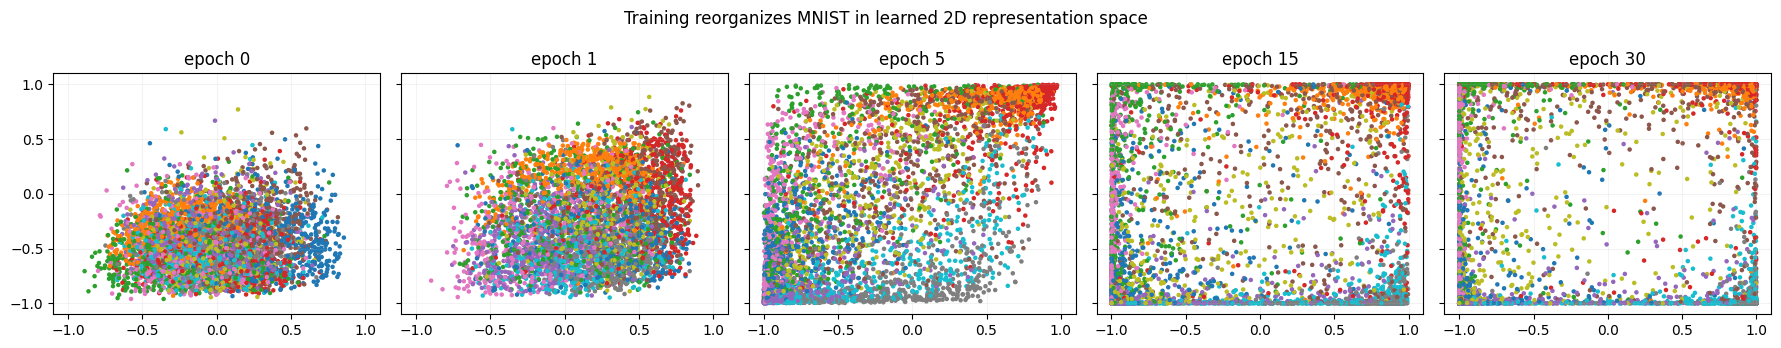

In [3]:
epochs=sorted(snapshots)
fig,axes=plt.subplots(1,len(epochs),figsize=(18,3.5),sharex=True,sharey=True)
for ax,e in zip(axes,epochs):
    H=snapshots[e]
    sc=ax.scatter(H[:,0],H[:,1],c=y_train,s=5,cmap='tab10')
    ax.set_title(f'epoch {e}'); ax.grid(alpha=.15)
plt.suptitle('Training reorganizes MNIST in learned 2D representation space')
plt.tight_layout(); plt.show()


## What actually changed?

The pixels did not move. The labels did not move. The **parameters changed**, so the mapping from pixels to hidden coordinates changed. The output layer then receives a progressively different geometry.

This is why deep learning is often more powerful than manually engineered features: the intermediate feature system itself is optimized for the task.

## Business analogy

In fraud detection, a hidden representation might reorganize transactions so fraudulent and legitimate behavior become easier to separate. In product classification, it may reorganize descriptions so product families cluster naturally. The final classifier can be simple because earlier layers learned a useful geometry.
